In [1]:
# include .. in the path
import os
import sys
sys.path.append("..")

import constants
from desiutil.log import log
import fitsio

from astropy.table import Table, vstack
import numpy as np
from matplotlib import pyplot as plt

In [2]:


def read_catalog(qsocat, balmask, bytile):
    """
    read quasar catalog

    Arguments
    ---------
    qsocat (str) : path to quasar catalog
    balmask (bool) : should BAL attributes from baltools be read in?
    bytile (bool) : catalog is tilebased, default assumption is healpix

    Returns
    -------
    table of relevant attributes for quasars defined in constants.py

    """
    if constants.no_bal:
        balmask = True

    if balmask:
        try:
            # read the following columns from qsocat
            cols = [
                "TARGETID",
                "TARGET_RA",
                "TARGET_DEC",
                "Z",
                "HPXPIXEL",
                "AI_CIV",
                "NCIV_450",
                "VMIN_CIV_450",
                "VMAX_CIV_450",
                "SPECTYPE",
                "ZWARN",
            ]
            if bytile:
                cols = [
                    "TARGETID",
                    "TARGET_RA",
                    "TARGET_DEC",
                    "Z",
                    "TILEID",
                    "PETAL_LOC",
                    "AI_CIV",
                    "NCIV_450",
                    "VMIN_CIV_450",
                    "VMAX_CIV_450",
                    "SPECTYPE",
                    "ZWARN",
                ]
            catalog = Table(fitsio.read(qsocat, ext=1, columns=cols))
        except:
            log.error(f"cannot find {cols} in quasar catalog")
            exit(1)
    else:
        # read the following columns from qsocat
        cols = [
            "TARGETID",
            "TARGET_RA",
            "TARGET_DEC",
            "Z",
            "HPXPIXEL",
            "SPECTYPE",
            "ZWARN",
        ]
        if bytile:
            cols = [
                "TARGETID",
                "TARGET_RA",
                "TARGET_DEC",
                "Z",
                "TILEID",
                "PETAL_LOC",
                "SPECTYPE",
                "ZWARN",
            ]
        catalog = Table(fitsio.read(qsocat, ext=1, columns=cols))

    log.info(f"Successfully read quasar catalog: {qsocat}")

    # Apply redshift cuts
    zmask = (catalog["Z"] > constants.zmin_qso) & (catalog["Z"] < constants.zmax_qso)
    log.info(f"objects in catalog: {len(catalog)} ")
    log.info(
        f"restricting to {constants.zmin_qso} < z < {constants.zmax_qso}: {np.sum(zmask)} objects remain"
    )

    # Apply bal mask
    if constants.no_bal:
        balind = catalog["NCIV_450"] > 0
        zmask = zmask & ~balind
        log.info(f"objects in catalog without BAL: {np.sum(zmask)}")

    # Apply zwarning mask
    if constants.zwarning:
        zmask = zmask & (catalog["ZWARN"] == 0)
        log.info(f"objects in catalog without ZWARN: {np.sum(zmask)}")

    # Apply spectype mask
    if constants.is_qso:
        zmask = zmask & (catalog["SPECTYPE"] == "QSO")
        log.info(f"objects in catalog with SPECTYPE QSO: {np.sum(zmask)}")

    catalog = catalog[zmask]

    return catalog


def read_mock_catalog(qsocat, balmask, mockpath):
    """
    read quasar catalog

    Arguments
    ---------
    qsocat (str) : path to quasar catalog
    balmask (bool) : should BAL attributes be read in?
    mockpath (str) : path to mock data

    Returns
    -------
    table of relevant attributes for z>2 quasars

    """
    # read the following columns from qsocat
    cols = ["TARGETID", "RA", "DEC", "Z"]
    try:
        catalog = Table(fitsio.read(qsocat, ext=1, columns=cols))
    except:
        print("[Warning] cannot find TARGETID, RA, DEC, Z in quasar catalog")
        print("... using Saclay cols instead.")
        cols = ['TARGETID', 'TARGET_RA', 'TARGET_DEC', 'Z']
        catalog = Table(fitsio.read(qsocat, ext=1, columns=cols))

    log.info(f"Successfully read mock quasar catalog: {qsocat}")

    # Apply redshift cuts
    zmask = (catalog["Z"] > constants.zmin_qso) & (catalog["Z"] < constants.zmax_qso)
    log.info(f"objects in catalog: {len(catalog)} ")
    log.info(
        f"restricting to {constants.zmin_qso} < z < {constants.zmax_qso}: {np.sum(zmask)} objects remain"
    )

    catalog = catalog[zmask]

    if balmask:
        try:
            # open bal catalog
            balcat = os.path.join(mockpath, "bal_cat.fits")
            cols = ["TARGETID", "AI_CIV", "NCIV_450", "VMIN_CIV_450", "VMAX_CIV_450"]
            balcat = Table(fitsio.read(balcat, ext=1, columns=cols))

            # add columns to catalog
            ai = np.full(len(catalog), 0.0)
            nciv = np.full(len(catalog), 0)
            vmin = np.full((len(catalog), balcat["VMIN_CIV_450"].shape[1]), -1.0)
            vmax = np.full((len(catalog), balcat["VMIN_CIV_450"].shape[1]), -1.0)

            for i, tid in enumerate(catalog["TARGETID"]):
                if np.any(tid == balcat["TARGETID"]):
                    match = balcat[balcat["TARGETID"] == tid]
                    ai[i] = match["AI_CIV"]
                    nciv[i] = match["NCIV_450"]
                    vmin[i] = match["VMIN_CIV_450"]
                    vmax[i] = match["VMAX_CIV_450"]

            catalog.add_columns(
                [ai, nciv, vmin, vmax],
                names=["AI_CIV", "NCIV_450", "VMIN_CIV_450", "VMAX_CIV_450"],
            )

        except:
            log.error(f"cannot find mock bal_cat.fits in {mockpath}")
            exit(1)

    return catalog


## Get the TID list for training new GP on DESI Y3

In [27]:
qsocat = "../data/loa/QSO_cat_loa_main_dark_healpix_v2-altbal.fits"
dlacat = "../data/loa/dlacat-loa-main-dark.fits"

# QSO catalog
catalog = read_catalog(qsocat, True, False)
# DLA catalog
dla_catalog = Table(fitsio.read(dlacat, ext=1))

INFO:1159698755.py:78:read_catalog: Successfully read quasar catalog: ../data/loa/QSO_cat_loa_main_dark_healpix_v2-altbal.fits
INFO:1159698755.py:82:read_catalog: objects in catalog: 2776520 
INFO:1159698755.py:83:read_catalog: restricting to 2.0 < z < 7: 945968 objects remain


In [4]:
constants.zmax_qso = 7

catalog_new = read_catalog(qsocat, True, False)

INFO:1159698755.py:78:read_catalog: Successfully read quasar catalog: ../data/loa/QSO_cat_loa_main_dark_healpix_v2-altbal.fits
INFO:1159698755.py:82:read_catalog: objects in catalog: 2776520 
INFO:1159698755.py:83:read_catalog: restricting to 2.0 < z < 7: 945968 objects remain


In [5]:
ind = catalog["Z"] > 2.
ind &= catalog["Z"] < 4.25
print("Number of QSOs in the catalog:", ind.sum())

balind = catalog["NCIV_450"] > 0
ind &= ~balind
print("Number of QSOs in the catalog without BALs:", ind.sum())

zwarnind = catalog["ZWARN"] == 0
ind &= zwarnind
print("Number of QSOs in the catalog without ZWARN:", ind.sum())

spectypeind = catalog["SPECTYPE"] == "QSO"
ind &= spectypeind
print("Number of QSOs in the catalog with SPECTYPE == QSO:", ind.sum())

# remove DLA targets
# Match DLA catalog to QSO catalog
dlaind = np.isin(catalog["TARGETID"], dla_catalog["TARGETID"])
ind &= ~dlaind
print("Number of QSOs in the catalog without DLAs:", ind.sum())

Number of QSOs in the catalog: 942946
Number of QSOs in the catalog without BALs: 746735
Number of QSOs in the catalog without ZWARN: 724767
Number of QSOs in the catalog with SPECTYPE == QSO: 714652
Number of QSOs in the catalog without DLAs: 664904


Text(0.5, 0, 'Redshift')

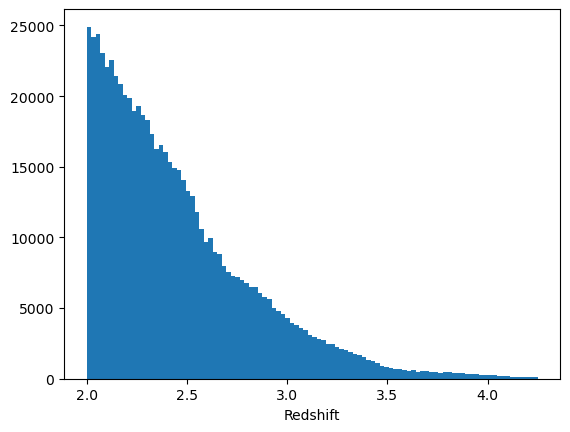

In [6]:
plt.hist(catalog[ind]["Z"], bins=100);
plt.xlabel("Redshift")


In [7]:
39627785479657905 in catalog["TARGETID"]

True

Very large DLAs (from Feige)

In [45]:
# P_DLA > 0.9, SNR > 4
ind = dla_catalog["P_DLA"] > 0.9
ind &= dla_catalog["SNR_REDSIDE"] > 4
print("Total number of DLAs after PDLA and SNR filter", ind.sum())

# Very large NHI > 22
ind &= dla_catalog["NHI"] > 21.5
print("Total number of DLAs after NHI filter", ind.sum())

# Check if there are other DLAs in the sigtline and delta ZDLA < 0.1
all_target_ids = dla_catalog[ind]["TARGETID"]
selected_target_ids = []
for this_target_id in all_target_ids:
    # min of delta zDLA < 0.1
    ind_this = this_target_id == all_target_ids
    this_z_dlas = dla_catalog[ind][ind_this]["Z_DLA"]
    if len(this_z_dlas) > 1:
        if np.abs(np.diff(this_z_dlas)).min() < 0.1:
            selected_target_ids.append(this_target_id)

selected_target_ids = np.array(selected_target_ids)

zdlaind = np.isin(all_target_ids, selected_target_ids)
dla_catalog[ind][zdlaind]

Total number of DLAs after PDLA and SNR filter 87013
Total number of DLAs after NHI filter 3622


TARGETID,RA,DEC,Z_QSO,SNR_FOREST,SNR_REDSIDE,DLAID,Z_DLA,Z_DLA_ERR,NHI,NHI_ERR,DLAFLAG,P_DLA,P_NULL,LOGP_DLA,LOGP_NULL,MODEL_P
int64,float64,float64,float64,float64,float64,str20,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64
39633285394990971,120.07848558452909,52.457020462978456,3.206243721087778,5.788245453155773,13.57195862287847,39633285394990971000,2.165608239609562,0.04419677752922604,22.737333007687635,0.24766225378413925,0,1.0000000000000209,-2.0872192862952943e-14,-281.85517043553165,-403.9503339233793,2.254101069974223e-11
39633285394990971,120.07848558452909,52.457020462978456,3.206243721087778,5.788245453155773,13.57195862287847,39633285394990971001,2.209805017138752,0.0005283219129809603,22.98499526147185,0.0007299691202379619,0,1.0000000000000209,-2.0872192862952943e-14,-263.9010278005698,-403.9503339233793,0.0014137039088907364
39627951372763902,229.05599322272627,6.654012721629555,3.0342357784856806,3.462808866041356,6.441711584344509,39627951372763902000,2.6523311136000265,0.009377541568870025,21.532880747740332,0.27899877910515886,0,0.9999999999999707,2.930988785010413e-14,-996.8218536535201,-1274.6476737582318,1.1890317636548438e-05
39627951372763902,229.05599322272627,6.654012721629555,3.0342357784856806,3.462808866041356,6.441711584344509,39627951372763902001,2.6650012183739133,0.005960232020058615,21.75240553373522,0.07597170732244253,0,0.9999999999999707,2.930988785010413e-14,-985.4842961891433,-1274.6476737582318,0.9977738129925967
39632936386956101,234.77790656942838,32.83543713625844,3.733830241707365,1.3654537266949467,4.701442430851345,39632936386956101000,3.303595489945552,0.013207566099441053,21.5031174660888,0.4977620298687626,0,0.999999999999893,1.0702549957386509e-13,-1313.3927908229437,-1485.6845134090727,1.0383640981566683e-05
39632936386956101,234.77790656942838,32.83543713625844,3.733830241707365,1.3654537266949467,4.701442430851345,39632936386956101001,3.3168030560449933,1.0142330892930705e-06,22.000879495957562,1.3172895861558173e-05,0,0.999999999999893,1.0702549957386509e-13,-1302.987605343827,-1485.6845134090727,0.3429764497899597
39633054037181465,221.65645928337244,38.82455111952272,2.8532690842670547,4.554597953917417,8.584650018705032,39633054037181465000,2.2740755398265238,0.016199351170461295,21.574770654142636,0.2818002002455954,0,0.9999999999999826,1.7430501486614958e-14,-695.2052029878832,-833.9136592545285,5.718133452134124e-10
39633054037181465,221.65645928337244,38.82455111952272,2.8532690842670547,4.554597953917417,8.584650018705032,39633054037181465001,2.2559890347336147,0.009555750520861215,21.80668375737209,0.08933304388792884,0,0.9999999999999826,1.7430501486614958e-14,-682.5157292036401,-833.9136592545285,0.00018544824582046989
39627532365991289,2.698895340792967,-10.448472937803793,3.334850455982275,11.406994967156303,27.431896432825155,39627532365991289000,2.2794257210321436,0.017139385937711193,22.218112692999668,0.296213073575209,0,0.999999999999996,3.9968028886505635e-15,123.39454873084502,-100.82664131372455,0.06795992876601564


In [47]:
_ind = dla_catalog[ind][zdlaind]["Z_QSO"] > 3
dla_catalog[ind][zdlaind][_ind]

TARGETID,RA,DEC,Z_QSO,SNR_FOREST,SNR_REDSIDE,DLAID,Z_DLA,Z_DLA_ERR,NHI,NHI_ERR,DLAFLAG,P_DLA,P_NULL,LOGP_DLA,LOGP_NULL,MODEL_P
int64,float64,float64,float64,float64,float64,str20,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64
39633285394990971,120.07848558452909,52.457020462978456,3.206243721087778,5.788245453155773,13.57195862287847,39633285394990971000,2.165608239609562,0.04419677752922604,22.737333007687635,0.24766225378413925,0,1.0000000000000209,-2.0872192862952943e-14,-281.85517043553165,-403.9503339233793,2.254101069974223e-11
39633285394990971,120.07848558452909,52.457020462978456,3.206243721087778,5.788245453155773,13.57195862287847,39633285394990971001,2.209805017138752,0.0005283219129809603,22.98499526147185,0.0007299691202379619,0,1.0000000000000209,-2.0872192862952943e-14,-263.9010278005698,-403.9503339233793,0.0014137039088907364
39627951372763902,229.05599322272627,6.654012721629555,3.0342357784856806,3.462808866041356,6.441711584344509,39627951372763902000,2.6523311136000265,0.009377541568870025,21.532880747740332,0.27899877910515886,0,0.9999999999999707,2.930988785010413e-14,-996.8218536535201,-1274.6476737582318,1.1890317636548438e-05
39627951372763902,229.05599322272627,6.654012721629555,3.0342357784856806,3.462808866041356,6.441711584344509,39627951372763902001,2.6650012183739133,0.005960232020058615,21.75240553373522,0.07597170732244253,0,0.9999999999999707,2.930988785010413e-14,-985.4842961891433,-1274.6476737582318,0.9977738129925967
39632936386956101,234.77790656942838,32.83543713625844,3.733830241707365,1.3654537266949467,4.701442430851345,39632936386956101000,3.303595489945552,0.013207566099441053,21.5031174660888,0.4977620298687626,0,0.999999999999893,1.0702549957386509e-13,-1313.3927908229437,-1485.6845134090727,1.0383640981566683e-05
39632936386956101,234.77790656942838,32.83543713625844,3.733830241707365,1.3654537266949467,4.701442430851345,39632936386956101001,3.3168030560449933,1.0142330892930705e-06,22.000879495957562,1.3172895861558173e-05,0,0.999999999999893,1.0702549957386509e-13,-1302.987605343827,-1485.6845134090727,0.3429764497899597
39627532365991289,2.698895340792967,-10.448472937803793,3.334850455982275,11.406994967156303,27.431896432825155,39627532365991289000,2.2794257210321436,0.017139385937711193,22.218112692999668,0.296213073575209,0,0.999999999999996,3.9968028886505635e-15,123.39454873084502,-100.82664131372455,0.06795992876601564
39627532365991289,2.698895340792967,-10.448472937803793,3.334850455982275,11.406994967156303,27.431896432825155,39627532365991289001,2.2620918977800075,1.3220349414323684e-12,22.737333007687635,8.55231069805325e-12,0,0.999999999999996,3.9968028886505635e-15,125.60540938817013,-100.82664131372455,0.6200368464015161
39627604340245771,23.694156523575323,-7.547061256589974,3.516018687928775,2.26157810008268,9.19413381648998,39627604340245771001,2.679848696329078,6.213180427154858e-06,22.878603546845426,1.1251335482301872e-05,0,0.9999999999999992,7.771561172376096e-16,-46.313052672722065,-396.2991788332065,1.0436902445912826e-12


## LOA CDDF target catalog

In [8]:
ind = catalog["Z"] > 2.15
ind &= catalog["Z"] < 6
print("Number of QSOs in the catalog:", ind.sum())

balind = catalog["NCIV_450"] > 0
ind &= ~balind
print("Number of QSOs in the catalog without BALs:", ind.sum())

zwarnind = catalog["ZWARN"] == 0
ind &= zwarnind
print("Number of QSOs in the catalog without ZWARN:", ind.sum())

spectypeind = catalog["SPECTYPE"] == "QSO"
ind &= spectypeind
print("Number of QSOs in the catalog with SPECTYPE == QSO:", ind.sum())

# remove DLA targets
# Match DLA catalog to QSO catalog
# dlaind = np.isin(catalog["TARGETID"], dla_catalog["TARGETID"])
# ind &= ~dlaind
# print("Number of QSOs in the catalog without DLAs:", ind.sum())

Number of QSOs in the catalog: 747471
Number of QSOs in the catalog without BALs: 582059
Number of QSOs in the catalog without ZWARN: 566609
Number of QSOs in the catalog with SPECTYPE == QSO: 560658


In [9]:
catalog[ind].write("../data/loa/cddf-qsocat-altbal_zgt2.15_zlt6.fits", overwrite=True)

In [22]:
ind = catalog["Z"] > 2.6
ind &= catalog["Z"] < 6
print("Number of QSOs in the catalog:", ind.sum())

balind = catalog["NCIV_450"] > 0
ind &= ~balind
print("Number of QSOs in the catalog without BALs:", ind.sum())

zwarnind = catalog["ZWARN"] == 0
ind &= zwarnind
print("Number of QSOs in the catalog without ZWARN:", ind.sum())

spectypeind = catalog["SPECTYPE"] == "QSO"
ind &= spectypeind
print("Number of QSOs in the catalog with SPECTYPE == QSO:", ind.sum())

# remove DLA targets
# Match DLA catalog to QSO catalog
# dlaind = np.isin(catalog["TARGETID"], dla_catalog["TARGETID"])
# ind &= ~dlaind
# print("Number of QSOs in the catalog without DLAs:", ind.sum())

Number of QSOs in the catalog: 309021
Number of QSOs in the catalog without BALs: 232756
Number of QSOs in the catalog without ZWARN: 227640
Number of QSOs in the catalog with SPECTYPE == QSO: 225770


In [23]:
catalog[ind].write("../data/loa/cddf-qsocat-altbal_zgt2.6_zlt6.fits", overwrite=True)

## Get the TID list for training new GP on DESI Mock

Mock

In [ ]:
qsocat = "../data/london/zcat.fits"
constants.zmax_qso = 4.25
catalog_london = read_mock_catalog(qsocat, False, "../data/london/")
constants.zmax_qso = 7
catalog_london_new = read_mock_catalog(qsocat, False, "../data/london/")

INFO:1159698755.py:133:read_mock_catalog: Successfully read mock quasar catalog: ../data/london/zcat.fits
INFO:1159698755.py:137:read_mock_catalog: objects in catalog: 1217878 
INFO:1159698755.py:138:read_mock_catalog: restricting to 2.0 < z < 4.25: 926122 objects remain
INFO:1159698755.py:133:read_mock_catalog: Successfully read mock quasar catalog: ../data/london/zcat.fits
INFO:1159698755.py:137:read_mock_catalog: objects in catalog: 1217878 
INFO:1159698755.py:138:read_mock_catalog: restricting to 2.0 < z < 7: 926122 objects remain


In [10]:
dlacat_london = Table.read("../data/london/dlacat-v5.9.5-mockcat.fits")
balcat_london = Table.read("../data/london/bal_cat.fits")

In [14]:
ind = catalog_london_new["Z"] > 2.
ind &= catalog_london_new["Z"] < 4.25
print("Number of QSOs in the catalog:", ind.sum())

balind = np.isin(catalog_london_new["TARGETID"], balcat_london["TARGETID"])
ind &= ~balind
print("Number of QSOs in the catalog without BALs:", ind.sum())

# zwarnind = catalog_london_new["ZWARN"] == 0
# ind &= zwarnind
# print("Number of QSOs in the catalog without ZWARN:", ind.sum())

# spectypeind = catalog_london_new["SPECTYPE"] == "QSO"
# ind &= spectypeind
# print("Number of QSOs in the catalog with SPECTYPE == QSO:", ind.sum())

# remove DLA targets
# Match DLA catalog to QSO catalog
dlaind = np.isin(catalog_london_new["TARGETID"], dlacat_london["TARGETID"])
ind &= ~dlaind
print("Number of QSOs in the catalog without DLAs:", ind.sum())

Number of QSOs in the catalog: 926122
Number of QSOs in the catalog without BALs: 778043
Number of QSOs in the catalog without DLAs: 712104


In [16]:
# save the catalog
catalog_london_new[ind].write("../data/london/gp_trainset_london.fits", overwrite=True)

## Mock CDDF target catalog

In [24]:
qsocat = "../data/london/zcat.fits"
catalog_london_new = read_mock_catalog(qsocat, False, "../data/london/")

balcat_london = Table.read("../data/london/bal_cat.fits")

INFO:1159698755.py:133:read_mock_catalog: Successfully read mock quasar catalog: ../data/london/zcat.fits
INFO:1159698755.py:137:read_mock_catalog: objects in catalog: 1217878 
INFO:1159698755.py:138:read_mock_catalog: restricting to 2.0 < z < 7: 926122 objects remain


In [13]:
ind = catalog_london_new["Z"] > 2.15
ind &= catalog_london_new["Z"] < 6
print("Number of QSOs in the catalog:", ind.sum())

balind = np.isin(catalog_london_new["TARGETID"], balcat_london["TARGETID"])
ind &= ~balind
print("Number of QSOs in the catalog without BALs:", ind.sum())

# zwarnind = catalog_london_new["ZWARN"] == 0
# ind &= zwarnind
# print("Number of QSOs in the catalog without ZWARN:", ind.sum())

# spectypeind = catalog_london_new["SPECTYPE"] == "QSO"
# ind &= spectypeind
# print("Number of QSOs in the catalog with SPECTYPE == QSO:", ind.sum())

Number of QSOs in the catalog: 731943
Number of QSOs in the catalog without BALs: 615039


In [14]:
catalog_london_new[ind].write("../data/london/cddf-qsocat_zgt2.15_zlt6.fits", overwrite=True)

In [20]:
ind = catalog_london_new["Z"] > 2.6
ind &= catalog_london_new["Z"] < 6
print("Number of QSOs in the catalog:", ind.sum())

balind = np.isin(catalog_london_new["TARGETID"], balcat_london["TARGETID"])
ind &= ~balind
print("Number of QSOs in the catalog without BALs:", ind.sum())

# zwarnind = catalog_london_new["ZWARN"] == 0
# ind &= zwarnind
# print("Number of QSOs in the catalog without ZWARN:", ind.sum())

# spectypeind = catalog_london_new["SPECTYPE"] == "QSO"
# ind &= spectypeind
# print("Number of QSOs in the catalog with SPECTYPE == QSO:", ind.sum())



Number of QSOs in the catalog: 289940
Number of QSOs in the catalog without BALs: 243843


In [21]:
catalog_london_new[ind].write("../data/london/cddf-qsocat_zgt2.6_zlt6.fits", overwrite=True)